In [1]:
# Step 1: Install required libraries
!pip install yfinance --quiet
!pip install keras --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install ta --quiet   # for technical indicators like RSI
!pip install streamlit --quiet  # optional, for dashboard

# Step 2: Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import ta

# Step 3: Fetch stock data
# Replace 'AAPL' with any stock ticker you want
ticker = 'AAPL'
data = yf.download(ticker, start='2015-01-01', end='2026-01-01')
data.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.2 MB/s eta 0:00:00


/tmp/ipykernel_10110/1092263330.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2015-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532728,24.064291,23.346682,23.984557,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000


In [2]:
# Step 4: Select closing price
closing_data = data['Close'].values
closing_data = closing_data.reshape(-1,1)

# Step 5: Normalize data (0 to 1)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_data)

# Step 6: Prepare sequences
sequence_length = 60  # last 60 days to predict next day
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i,0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # reshape for LSTM

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2706, 60, 1)
y shape: (2706,)


In [3]:
# Step 7: Build LSTM model
model = Sequential()

# First LSTM layer with Dropout
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 8: Train the model
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.0091 - val_loss: 0.0013
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0014 - val_loss: 0.0030
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0013 - val_loss: 0.0023
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0011 - val_loss: 0.0061
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0010 - val_loss: 0.0080
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0010 - val_l

/tmp/ipykernel_10110/1277044335.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(ticker, start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


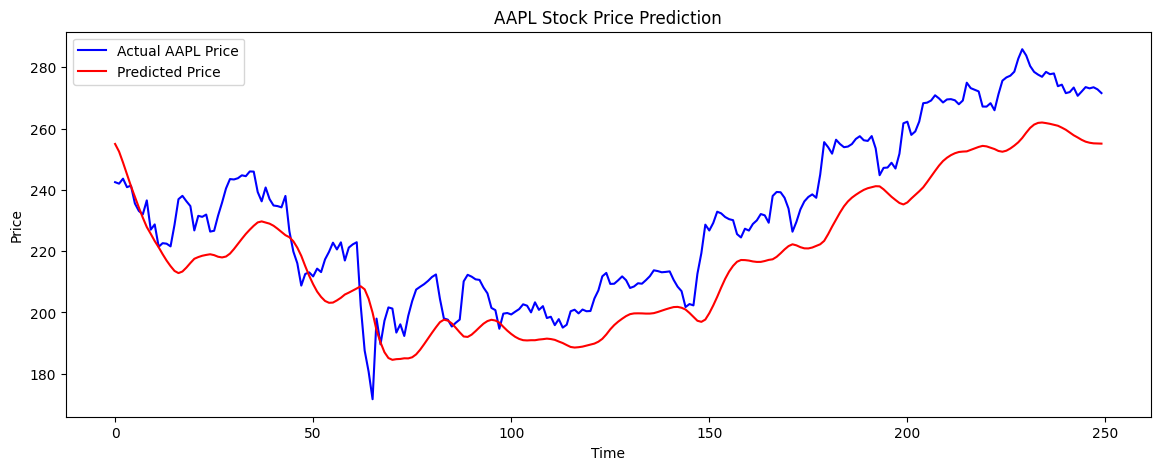

In [4]:
# Step 9: Prepare test data
test_start = '2025-01-01'  # adjust as needed
test_end = '2026-01-01'

test_data = yf.download(ticker, start=test_start, end=test_end)
actual_prices = test_data['Close'].values

# Combine training + test to scale properly
total_data = pd.concat((data['Close'], test_data['Close']), axis=0)
inputs = total_data[len(total_data) - len(test_data) - sequence_length:].values
inputs = inputs.reshape(-1,1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(sequence_length, len(inputs)):
    X_test.append(inputs[i-sequence_length:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Step 10: Predict
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Step 11: Plot actual vs predicted
plt.figure(figsize=(14,5))
plt.plot(actual_prices, color='blue', label=f'Actual {ticker} Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [7]:
# Step 5: Add Moving Averages & RSI as features for LSTM

import ta
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Ensure Close is a 1D Series
data['MA50'] = data['Close']['AAPL'].rolling(window=50).mean()
data['MA200'] = data['Close']['AAPL'].rolling(window=200).mean()
data['RSI'] = ta.momentum.RSIIndicator(data['Close']['AAPL'], window=14).rsi()

# Drop NaNs created by MA and RSI
data_ind = data.dropna().reset_index(drop=True)

# Select features: Close price + indicators
features = data_ind[['Close', 'MA50', 'MA200', 'RSI']].values

# Scale features between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_features = scaler.fit_transform(features)

# Prepare sequences for LSTM
sequence_length = 60
X_ind = []
y_ind = []

for i in range(sequence_length, len(scaled_features)):
    X_ind.append(scaled_features[i-sequence_length:i])
    y_ind.append(scaled_features[i,0])  # Predicting Close price

X_ind, y_ind = np.array(X_ind), np.array(y_ind)

print("X_ind shape:", X_ind.shape)  # (samples, 60, 4)
print("y_ind shape:", y_ind.shape)  # (samples,)

X_ind shape: (2507, 60, 4)
y_ind shape: (2507,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 6: Build multi-feature LSTM
model_ind = Sequential()

# First LSTM layer
model_ind.add(LSTM(units=50, return_sequences=True, input_shape=(X_ind.shape[1], X_ind.shape[2])))
model_ind.add(Dropout(0.2))

# Second LSTM layer
model_ind.add(LSTM(units=50, return_sequences=False))
model_ind.add(Dropout(0.2))

# Output layer
model_ind.add(Dense(units=1))  # predicting Close price

# Compile the model
model_ind.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history_ind = model_ind.fit(X_ind, y_ind, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0142 - val_loss: 0.0060
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0011 - val_loss: 9.6754e-04
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0013 - v

/tmp/ipykernel_10110/2930526593.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(ticker, start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step


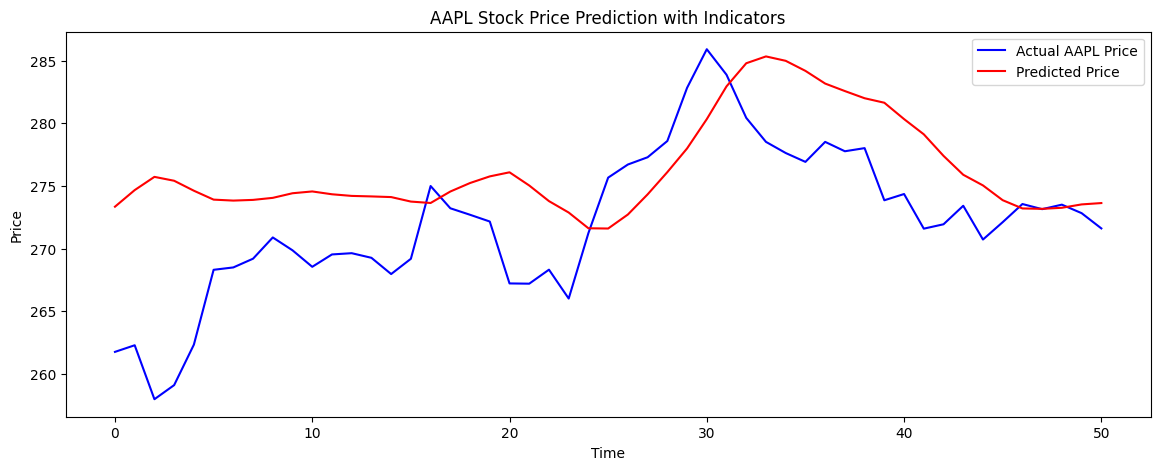

In [10]:
# Step 7: Prepare test data
test_start = '2025-01-01'  # adjust as needed
test_end = '2026-01-01'

test_data = yf.download(ticker, start=test_start, end=test_end)
test_data['MA50'] = test_data['Close']['AAPL'].rolling(window=50).mean()
test_data['MA200'] = test_data['Close']['AAPL'].rolling(window=200).mean()
test_data['RSI'] = ta.momentum.RSIIndicator(test_data['Close']['AAPL'], window=14).rsi()

# Drop NaNs
test_data = test_data.dropna().reset_index(drop=True)

# Combine training + test for proper scaling
total_data = pd.concat([data_ind[['Close','MA50','MA200','RSI']], test_data[['Close','MA50','MA200','RSI']]], axis=0)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_total = scaler.fit_transform(total_data)

# Prepare sequences for test
X_test = []
y_test = test_data['Close']['AAPL'].values

sequence_length = 60
for i in range(len(data_ind), len(scaled_total)):
    X_test.append(scaled_total[i-sequence_length:i])

X_test = np.array(X_test)

# Predict
predicted_prices = model_ind.predict(X_test)
predicted_prices = scaler.inverse_transform(
    np.concatenate((predicted_prices, np.zeros((predicted_prices.shape[0],3))), axis=1)
)[:,0]  # only take predicted Close

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test, color='blue', label=f'Actual {ticker} Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')
plt.title(f'{ticker} Stock Price Prediction with Indicators')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [11]:
# Step 8: Save the model
model_ind.save('lstm_stock_model.h5')
print("Model saved as lstm_stock_model.h5")

Model saved as lstm_stock_model.h5


In [12]:
from tensorflow.keras.models import load_model

model = load_model('lstm_stock_model.h5')

In [13]:
# Save this as app.py and run: streamlit run app.py
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

st.title("Stock Price Prediction Dashboard")

ticker = st.text_input("Enter Stock Ticker", "AAPL")
days_to_predict = st.number_input("Days to predict ahead", 1, 30, 1)

if st.button("Predict"):
    data = yf.download(ticker, period="5y")
    data['MA50'] = data['Close'].rolling(window=50).mean()
    data['MA200'] = data['Close'].rolling(window=200).mean()
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
    data = data.dropna()

    features = data[['Close','MA50','MA200','RSI']].values
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_features = scaler.fit_transform(features)

    # Load model
    model = load_model('lstm_stock_model.h5')

    # Predict next day(s)
    last_sequence = scaled_features[-60:]
    X_input = last_sequence.reshape(1, last_sequence.shape[0], last_sequence.shape[1])

    prediction = model.predict(X_input)
    predicted_price = scaler.inverse_transform(np.concatenate((prediction, np.zeros((1,3))), axis=1))[0,0]

    st.write(f"Predicted next day price for {ticker}: ${predicted_price:.2f}")

2026-03-26 08:38:35.741 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.130 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-26 08:38:36.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:38:36.144 Thread 'MainThread': mi

In [14]:
# app.py
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import ta

st.title("Stock Price Prediction Dashboard")

ticker = st.text_input("Enter Stock Ticker", "AAPL")
days_to_predict = st.number_input("Days to predict ahead", 1, 30, 1)

if st.button("Predict"):
    data = yf.download(ticker, period="5y")
    data['MA50'] = data['Close'].rolling(window=50).mean()
    data['MA200'] = data['Close'].rolling(window=200).mean()
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
    data = data.dropna()

    features = data[['Close','MA50','MA200','RSI']].values
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_features = scaler.fit_transform(features)

    # Load the trained model
    model = load_model('lstm_stock_model.h5')

    # Prepare last 60-day sequence for prediction
    last_sequence = scaled_features[-60:]
    X_input = last_sequence.reshape(1, last_sequence.shape[0], last_sequence.shape[1])

    # Predict next day price
    prediction = model.predict(X_input)
    predicted_price = scaler.inverse_transform(np.concatenate((prediction, np.zeros((1,3))), axis=1))[0,0]

    st.write(f"Predicted next day price for {ticker}: ${predicted_price:.2f}")

2026-03-26 08:40:09.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.891 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 08:40:09.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar